In [3]:
from engine import Value, Neuron, Layer, MLP
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                #recursion to build edges and nodes for child
                #child is new root from here
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape= 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [5]:
a = Value(2.0)
a * 2


value(data = 4.0)

In [6]:
#inputs(2)
x1 = Value (2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.8813735870195432, label='b') 
x1w1 = x1*w1; x1w1.label = 'x1*w1' 
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n= x1w1x2w2+ b; n.label = 'n'
o = n.tanh(); o.label = 'o'

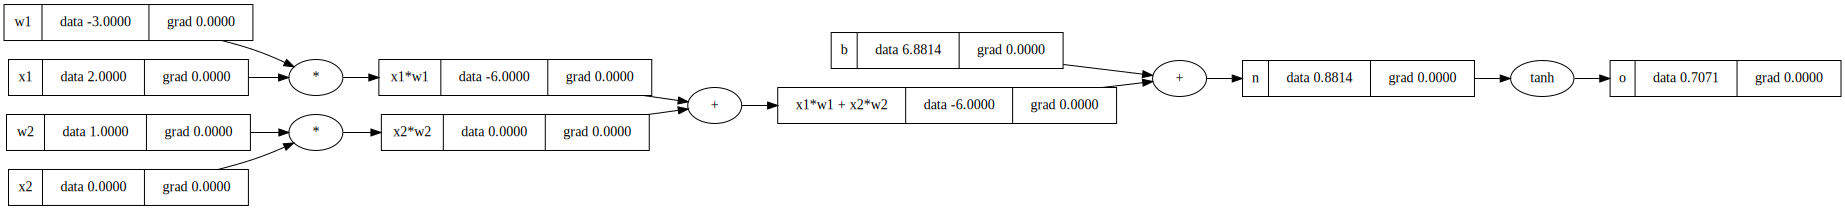

In [7]:
draw_dot(o)

In [8]:
o.backward()

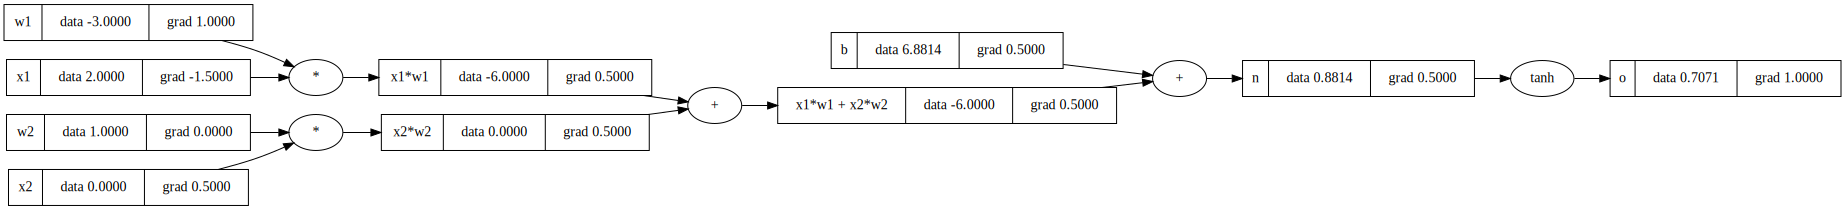

In [9]:
draw_dot(o)

In [10]:
topo = []
visited = set()

def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
       build_topo(child)
    topo.append(v)
build_topo(o)
topo
        

[value(data = 2.0),
 value(data = -3.0),
 value(data = -6.0),
 value(data = 1.0),
 value(data = 0.0),
 value(data = 0.0),
 value(data = -6.0),
 value(data = 6.881373587019543),
 value(data = 0.8813735870195432),
 value(data = 0.7071067811865476)]

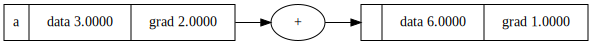

In [11]:
a = Value(3.0, label='a')
b = a + a
b.backward()
draw_dot(b)

In [12]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x) 

value(data = 0.18308880530182017)

In [13]:
n.parameters()

[value(data = 0.3026752811743263),
 value(data = 0.6101870812960173),
 value(data = 0.7675993195420583),
 value(data = 0.7250363860904216),
 value(data = -0.9283217693514847),
 value(data = 0.21475474463915467),
 value(data = 0.4227199337722538),
 value(data = 0.3992803856580931),
 value(data = 0.8110940482632085),
 value(data = -0.14826443865665628),
 value(data = -0.7885287858505075),
 value(data = 0.4926902571897489),
 value(data = 0.7016356880234211),
 value(data = 0.6947261810295267),
 value(data = 0.0328531497673854),
 value(data = -0.20737502375658368),
 value(data = 0.14347734185573624),
 value(data = -0.2601995985735033),
 value(data = 0.6325213884573067),
 value(data = 0.8610208306668776),
 value(data = -0.8359335846306974),
 value(data = 0.5834266142981701),
 value(data = 0.891016269194624),
 value(data = 0.5098815868770417),
 value(data = 0.08593971332689665),
 value(data = -0.7616960907639487),
 value(data = -0.8625948334391125),
 value(data = -0.3380194261122278),
 value(

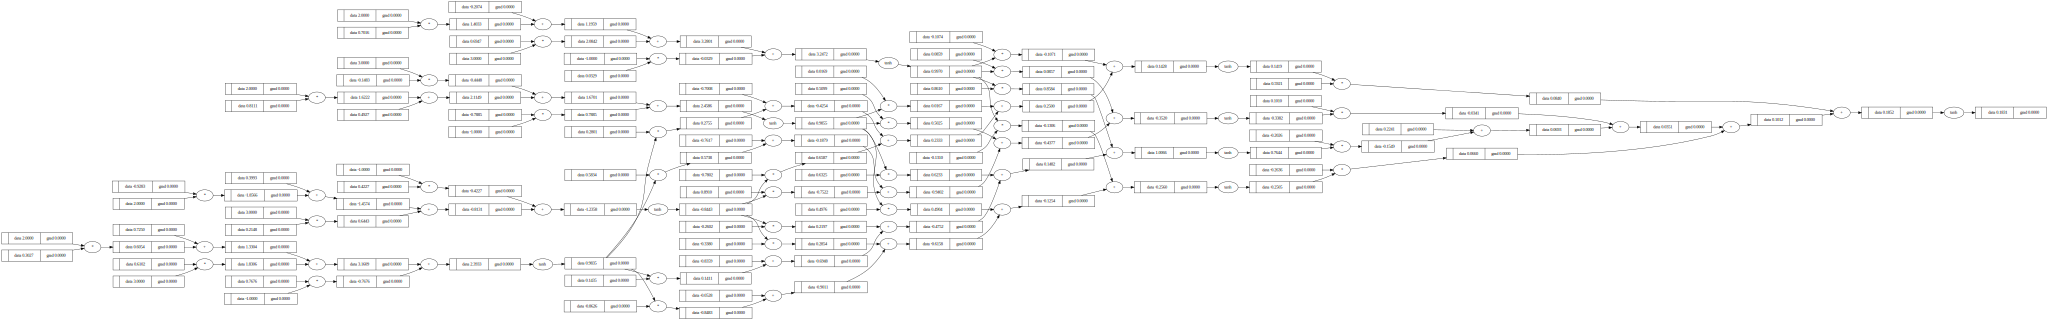

In [14]:
draw_dot(n(x))

In [15]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] ##desired targets or ground truths(ygt)


In [215]:
for k in range(10):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    #backwards pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.01 * p.grad

    print(k, loss.data)

0 6.0001298640202005
1 5.76776555049171
2 5.490953765781063
3 5.155519860697265
4 4.742855378172938
5 4.236448777614178
6 3.637147056457234
7 2.9860511438133095
8 2.371038783666121
9 1.8784073415533171
